# EPG Spatial Transfer Diagnostics

This notebook diagnoses why the spatial random-forest workflow is weak for `EPG heating` and `EPG cooling`. It reads the latest saved training outputs and does not retrain the random forests.

The diagnosis focuses on four questions:

1. Does the trained model beat simple train-mean baselines under the same fixed-test and spatial-CV roles?
2. Are EPG target distributions and prediction biases shifted by NUTS3 region?
3. Where are large residuals located geographically?
4. Which allowed predictors are important or remain correlated with residual errors?


In [1]:
from __future__ import annotations

import json
import sys
from importlib import import_module, reload
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import TwoSlopeNorm
from sklearn.metrics import mean_absolute_error, r2_score

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
try:
    from IPython.display import display
except Exception:
    display = print

EPG_TARGETS = ["EPG heating", "EPG cooling"]

In [2]:
REPO_ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "pipeline" / "config").exists()
)
sys.path.append(str(REPO_ROOT))

from pipeline.utils.paths import load_paths, path_value, repo_data_path

rf_utils = reload(import_module("pipeline.3_epvi_prediction.utils"))
PATHS = load_paths()
MODEL_OUT_DIR = path_value(PATHS, "external_data_root") / "outputs" / "epvi_prediction" / "random_forest"
PARISH_GEOMETRY_GEOJSON = repo_data_path(PATHS, "parishes.geojson")

metrics_path = rf_utils.latest_file(MODEL_OUT_DIR, "rf_epvi_metrics_*.csv")
if metrics_path is None:
    raise FileNotFoundError(f"No RF metrics found in {MODEL_OUT_DIR}. Run model_training.ipynb first.")
stamp = metrics_path.stem.removeprefix("rf_epvi_metrics_")
predictions_path = MODEL_OUT_DIR / f"rf_epvi_predictions_residuals_{stamp}.csv"
importances_path = MODEL_OUT_DIR / f"rf_epvi_feature_importances_{stamp}.csv"
params_path = MODEL_OUT_DIR / f"rf_epvi_best_params_{stamp}.json"
folds_path = MODEL_OUT_DIR / f"rf_epvi_spatial_cv_folds_{stamp}.csv"
required = [metrics_path, predictions_path, importances_path, params_path, folds_path]
missing = [path for path in required if not path.exists()]
if missing:
    raise FileNotFoundError(f"Latest RF output stamp {stamp} is incomplete: {missing}")

print("output stamp:", stamp)
for path in required:
    print(" -", path)

output stamp: 20260526_000504
 - E:\OneDrive\Studia\Studia magisterskie\Masterarbeit 2 - Sozialwissenschaften\data\outputs\epvi_prediction\random_forest\rf_epvi_metrics_20260526_000504.csv
 - E:\OneDrive\Studia\Studia magisterskie\Masterarbeit 2 - Sozialwissenschaften\data\outputs\epvi_prediction\random_forest\rf_epvi_predictions_residuals_20260526_000504.csv
 - E:\OneDrive\Studia\Studia magisterskie\Masterarbeit 2 - Sozialwissenschaften\data\outputs\epvi_prediction\random_forest\rf_epvi_feature_importances_20260526_000504.csv
 - E:\OneDrive\Studia\Studia magisterskie\Masterarbeit 2 - Sozialwissenschaften\data\outputs\epvi_prediction\random_forest\rf_epvi_best_params_20260526_000504.json
 - E:\OneDrive\Studia\Studia magisterskie\Masterarbeit 2 - Sozialwissenschaften\data\outputs\epvi_prediction\random_forest\rf_epvi_spatial_cv_folds_20260526_000504.csv


In [3]:
metrics = pd.read_csv(metrics_path)
predictions = pd.read_csv(predictions_path)
importances = pd.read_csv(importances_path)
folds = pd.read_csv(folds_path)
with open(params_path, "r", encoding="utf-8") as f:
    best_params = json.load(f)

epg_metrics = metrics[metrics["target"].isin(EPG_TARGETS)].copy()
epg_predictions = predictions[predictions["target"].isin(EPG_TARGETS)].copy()
epg_importances = importances[importances["target"].isin(EPG_TARGETS)].copy()
epg_folds = folds[folds["target"].eq(EPG_TARGETS[0])].copy()

display(epg_metrics[[
    "target", "n_train_rows", "n_test_rows", "search_spatial_cv_r2_mean",
    "train_spatial_cv_r2", "fixed_test_r2", "fixed_test_rmse", "fixed_test_spearman",
]])
display(pd.DataFrame(best_params).T.loc[EPG_TARGETS])
display(epg_folds)

,target,n_train_rows,n_test_rows,search_spatial_cv_r2_mean,train_spatial_cv_r2,fixed_test_r2,fixed_test_rmse,fixed_test_spearman
2,EPG cooling,2474,618,0.037825,0.197139,0.366419,0.712319,0.637837
4,EPG heating,2474,618,0.090546,0.222595,0.001502,1.438909,0.137919


,model__n_estimators,model__min_samples_split,model__min_samples_leaf,model__max_features,model__max_depth
EPG heating,500,5,10,sqrt,6
EPG cooling,500,5,10,sqrt,6


,target,fold,n_rows,n_nuts3,validation_nuts3
0,EPG heating,0,478,4,"PT11A, PT11B, PT181, PT200"
1,EPG heating,1,490,5,"PT11C, PT150, PT16D, PT170, PT300"
2,EPG heating,2,504,4,"PT11D, PT16G, PT184, PT187"
3,EPG heating,3,503,4,"PT111, PT119, PT16H, PT185"
4,EPG heating,4,499,4,"PT11E, PT16E, PT16F, PT186"


## Baseline Check

A weak random forest can still be useful if it beats a baseline. The fixed-test baseline predicts the training-set target mean. The spatial-CV baseline predicts each held-out NUTS3 fold from the mean of the remaining training folds.

In [4]:
fold_by_nuts3 = {}
for row in epg_folds.itertuples(index=False):
    for nuts3 in row.validation_nuts3.split(", "):
        fold_by_nuts3[nuts3] = int(row.fold)

def role_metrics(target: str, role: str, observed, predicted, predictor_name: str) -> dict:
    return {
        "target": target,
        "prediction_role": role,
        "predictor": predictor_name,
        "n": len(observed),
        "r2": r2_score(observed, predicted),
        "mae": mean_absolute_error(observed, predicted),
        "rmse": rf_utils.rmse(observed, predicted),
        "mean_error": float(np.mean(observed - predicted)),
    }

baseline_rows = []
baseline_prediction_frames = []
for target in EPG_TARGETS:
    cv_t = epg_predictions.query("target == @target and prediction_role == 'train_spatial_cv'").copy()
    cv_t["fold"] = cv_t["NUTS3"].map(fold_by_nuts3)
    cv_t["baseline"] = np.nan
    for fold in sorted(cv_t["fold"].dropna().unique()):
        cv_t.loc[cv_t["fold"].eq(fold), "baseline"] = cv_t.loc[~cv_t["fold"].eq(fold), "observed"].mean()
    test_t = epg_predictions.query("target == @target and prediction_role == 'fixed_test'").copy()
    test_t["baseline"] = cv_t["observed"].mean()
    for role, data_t in [("train_spatial_cv", cv_t), ("fixed_test", test_t)]:
        baseline_rows.append(role_metrics(target, role, data_t["observed"], data_t["predicted"], "random_forest"))
        baseline_rows.append(role_metrics(target, role, data_t["observed"], data_t["baseline"], "train_mean_baseline"))
        baseline_prediction_frames.append(data_t.assign(prediction_role=role))

baseline_metrics = pd.DataFrame(baseline_rows)
baseline_predictions = pd.concat(baseline_prediction_frames, ignore_index=True)
display(baseline_metrics.sort_values(["target", "prediction_role", "predictor"]))

,target,prediction_role,predictor,n,r2,mae,rmse,mean_error
6,EPG cooling,fixed_test,random_forest,618,0.366419,0.539767,0.712319,0.073417
7,EPG cooling,fixed_test,train_mean_baseline,618,-0.025707,0.735880,0.906328,0.143483
4,EPG cooling,train_spatial_cv,random_forest,2474,0.197139,0.744587,0.998088,-0.008909
5,EPG cooling,train_spatial_cv,train_mean_baseline,2474,-0.063021,0.858587,1.148470,0.000820
2,EPG heating,fixed_test,random_forest,618,0.001502,0.956332,1.438909,0.171041
3,EPG heating,fixed_test,train_mean_baseline,618,-0.051265,1.043535,1.476440,0.326038
0,EPG heating,train_spatial_cv,random_forest,2474,0.222595,1.039283,1.602049,-0.070951
1,EPG heating,train_spatial_cv,train_mean_baseline,2474,-0.071676,1.263153,1.880979,0.001827


## Prediction Compression and Target Shift

These plots show whether the random forest collapses regional predictions toward the training mean and whether fixed-test target distributions are shifted relative to the spatial-CV training regions.

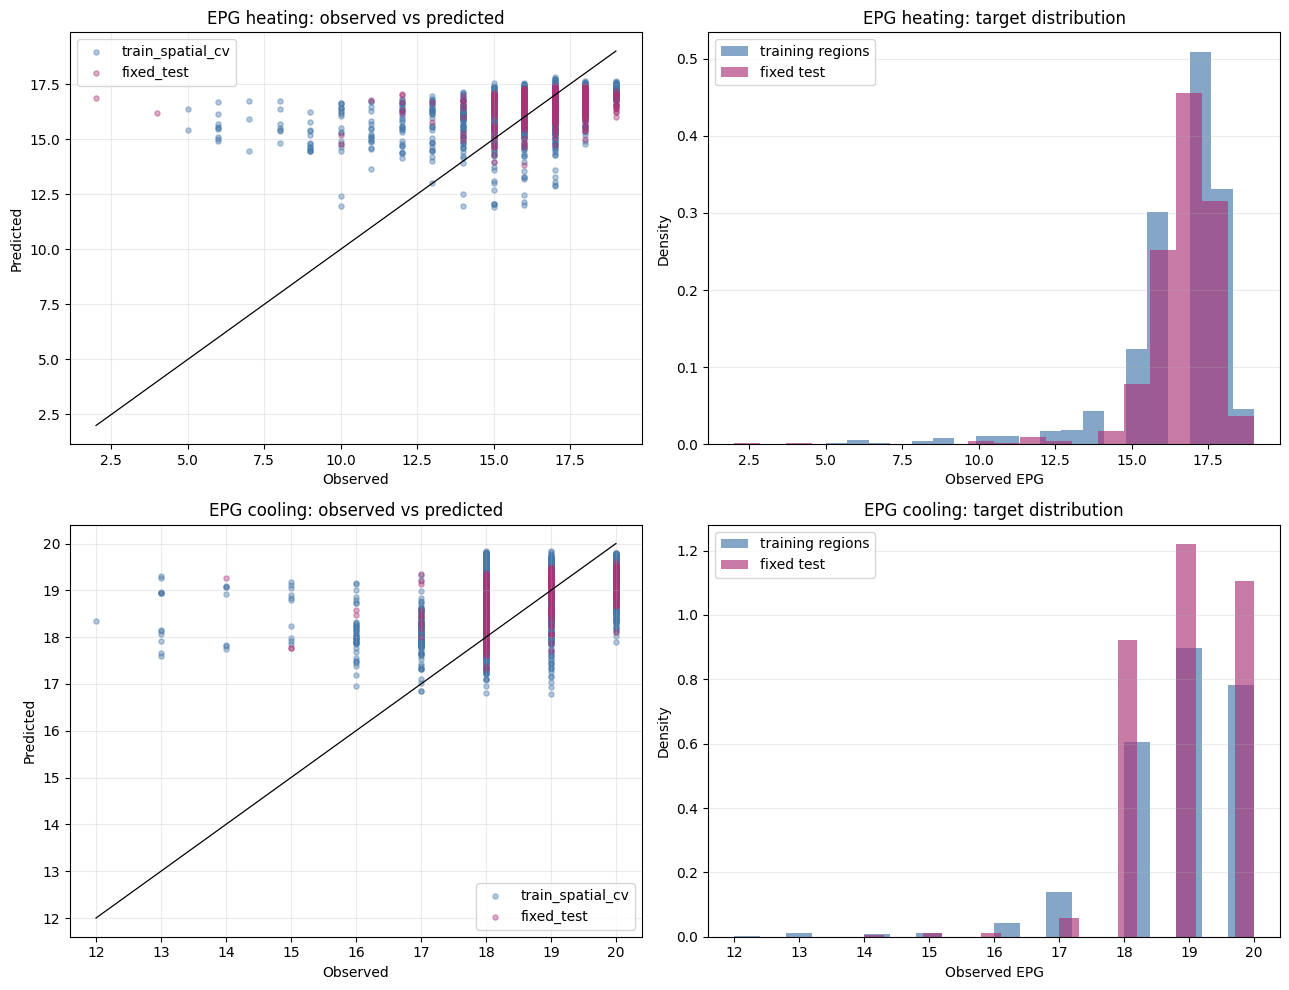

observed                             predicted  \
                                  min       mean   max       std        min   
target      prediction_role                                                   
EPG cooling fixed_test           14.0  18.988673  20.0  0.895623  17.326320   
            train_in_sample      12.0  18.845190  20.0  1.114132  16.004187   
            train_spatial_cv     12.0  18.845190  20.0  1.114132  16.782964   
EPG heating fixed_test            2.0  16.809061  19.0  1.441158  13.822114   
            train_in_sample       5.0  16.483023  19.0  1.817357  10.357677   
            train_spatial_cv      5.0  16.483023  19.0  1.817357  11.918841   

                                                              
                                   mean        max       std  
target      prediction_role                                   
EPG cooling fixed_test        18.915256  19.604433  0.464152  
            train_in_sample   18.846370  19.725953  0.669070  
            train_spatial_cv  18.854099  19.841687  0.587529  
EPG heating fixed_test        16.638021  17.423007  0.556876  
            train_in_sample   16.486996  18.012360  1.111738  
            train_spatial_cv  16.553974  17.842330  0.779689

,target,prediction_role,n,observed_mean,observed_std,share_epg_20,share_epg_19_or_20
0,EPG cooling,fixed_test,618,18.988673,0.895623,0.331715,0.697411
1,EPG cooling,train_in_sample,2474,18.845190,1.114132,0.313258,0.672595
2,EPG cooling,train_spatial_cv,2474,18.845190,1.114132,0.313258,0.672595
3,EPG heating,fixed_test,618,16.809061,1.441158,0.000000,0.030744
4,EPG heating,train_in_sample,2474,16.483023,1.817357,0.000000,0.031528
5,EPG heating,train_spatial_cv,2474,16.483023,1.817357,0.000000,0.031528


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for row, target in enumerate(EPG_TARGETS):
    ax = axes[row, 0]
    for role, color in [("train_spatial_cv", "#4477AA"), ("fixed_test", "#AA3377")]:
        part = epg_predictions.query("target == @target and prediction_role == @role")
        ax.scatter(part["observed"], part["predicted"], s=14, alpha=0.4, label=role, color=color)
    lo = epg_predictions.loc[epg_predictions["target"].eq(target), ["observed", "predicted"]].min().min()
    hi = epg_predictions.loc[epg_predictions["target"].eq(target), ["observed", "predicted"]].max().max()
    ax.plot([lo, hi], [lo, hi], color="black", linewidth=0.9)
    ax.set_title(f"{target}: observed vs predicted")
    ax.set_xlabel("Observed")
    ax.set_ylabel("Predicted")
    ax.grid(alpha=0.25)
    ax.legend()

    ax = axes[row, 1]
    train_vals = epg_predictions.query("target == @target and prediction_role == 'train_spatial_cv'")["observed"]
    test_vals = epg_predictions.query("target == @target and prediction_role == 'fixed_test'")["observed"]
    ax.hist(train_vals, bins=20, alpha=0.65, density=True, label="training regions", color="#4477AA")
    ax.hist(test_vals, bins=20, alpha=0.65, density=True, label="fixed test", color="#AA3377")
    ax.set_title(f"{target}: target distribution")
    ax.set_xlabel("Observed EPG")
    ax.set_ylabel("Density")
    ax.grid(axis="y", alpha=0.25)
    ax.legend()
plt.tight_layout()
plt.show()

range_summary = epg_predictions.groupby(["target", "prediction_role"])[["observed", "predicted"]].agg(["min", "mean", "max", "std"])
display(range_summary)

epg_observed_distribution = (
    epg_predictions.groupby(["target", "prediction_role"], observed=True)
    .agg(
        n=("observed", "size"),
        observed_mean=("observed", "mean"),
        observed_std=("observed", "std"),
        share_epg_20=("observed", lambda values: values.eq(20).mean()),
        share_epg_19_or_20=("observed", lambda values: values.ge(19).mean()),
    )
    .reset_index()
)
display(epg_observed_distribution)

## Region-Level Errors

Region means expose systematic NUTS3 biases that parish-level scatter plots can hide. Negative mean residuals are overprediction; positive mean residuals are underprediction.

,target,prediction_role,NUTS3,n,observed_mean,predicted_mean,residual_mean,mae,rmse
3,EPG cooling,fixed_test,PT16J,266.0,19.575188,19.173546,0.401642,0.808343,0.904431
1,EPG cooling,fixed_test,PT16B,89.0,18.191011,18.350429,-0.159418,0.548780,0.715002
2,EPG cooling,fixed_test,PT16I,93.0,18.032258,18.346636,-0.314378,0.444965,0.674908
0,EPG cooling,fixed_test,PT112,170.0,19.011765,19.117880,-0.106116,0.166670,0.218614
11,EPG cooling,train_spatial_cv,PT150,67.0,15.477612,18.332826,-2.855214,2.856944,3.410750
9,EPG cooling,train_spatial_cv,PT11D,217.0,18.290323,19.488547,-1.198224,1.223911,1.319700
24,EPG cooling,train_spatial_cv,PT300,54.0,18.037037,19.205278,-1.168241,1.168241,1.203574
17,EPG cooling,train_spatial_cv,PT170,118.0,17.516949,18.084200,-0.567251,0.921828,1.162263
20,EPG cooling,train_spatial_cv,PT185,68.0,17.441176,18.316420,-0.875243,1.003664,1.151273
19,EPG cooling,train_spatial_cv,PT184,62.0,18.387097,17.438947,0.948149,0.948149,1.086120


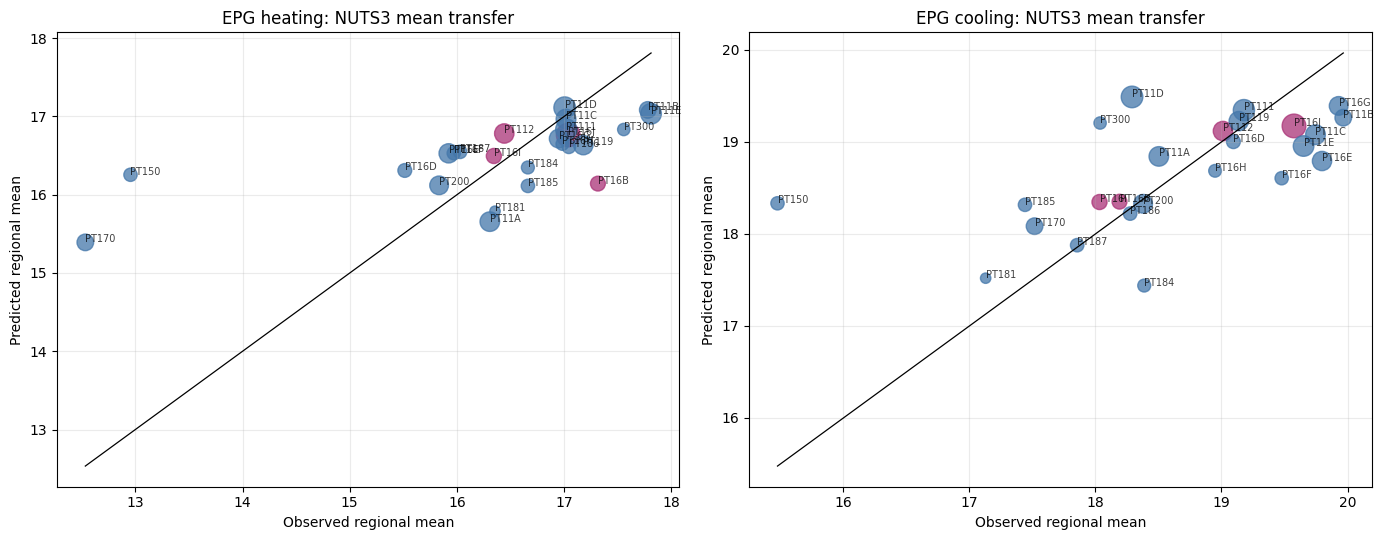

In [6]:
def regional_metrics(df: pd.DataFrame) -> pd.Series:
    return pd.Series({
        "n": len(df),
        "observed_mean": df["observed"].mean(),
        "predicted_mean": df["predicted"].mean(),
        "residual_mean": df["residual"].mean(),
        "mae": df["residual"].abs().mean(),
        "rmse": rf_utils.rmse(df["observed"], df["predicted"]),
    })

region_summary = (
    epg_predictions[epg_predictions["prediction_role"].isin(["train_spatial_cv", "fixed_test"])]
    .groupby(["target", "prediction_role", "NUTS3"], observed=True)
    .apply(regional_metrics, include_groups=False)
    .reset_index()
)
display(region_summary.sort_values(["target", "prediction_role", "rmse"], ascending=[True, True, False]).head(30))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, target in zip(axes, EPG_TARGETS):
    part = region_summary[region_summary["target"].eq(target)].copy()
    colors = part["prediction_role"].map({"train_spatial_cv": "#4477AA", "fixed_test": "#AA3377"})
    ax.scatter(part["observed_mean"], part["predicted_mean"], s=25 + part["n"], alpha=0.75, c=colors)
    lo = part[["observed_mean", "predicted_mean"]].min().min()
    hi = part[["observed_mean", "predicted_mean"]].max().max()
    ax.plot([lo, hi], [lo, hi], color="black", linewidth=0.9)
    for row in part.itertuples(index=False):
        ax.annotate(row.NUTS3, (row.observed_mean, row.predicted_mean), fontsize=7, alpha=0.75)
    ax.set_title(f"{target}: NUTS3 mean transfer")
    ax.set_xlabel("Observed regional mean")
    ax.set_ylabel("Predicted regional mean")
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Residual Maps

The maps use the same mainland-plus-insets layout as the index choropleths and outline municipality boundaries in black. Training maps show spatial-CV residuals in training regions. Fixed-test maps show residuals only in `PT16E` and `PT16J`.

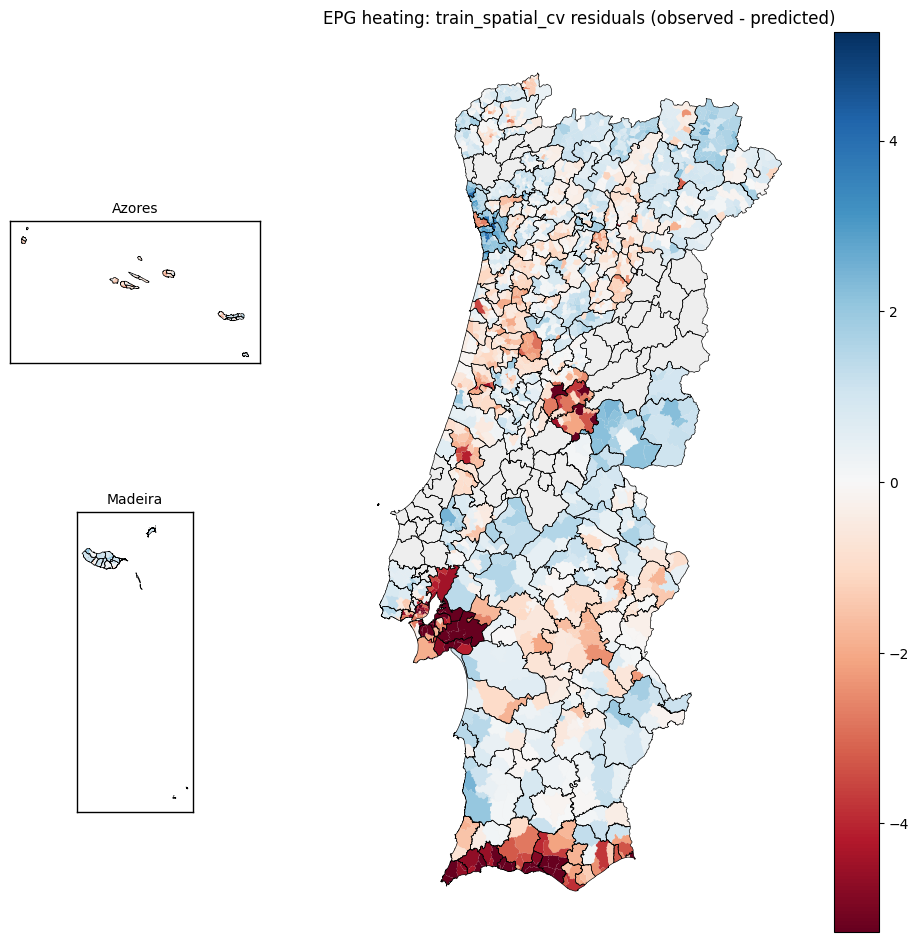

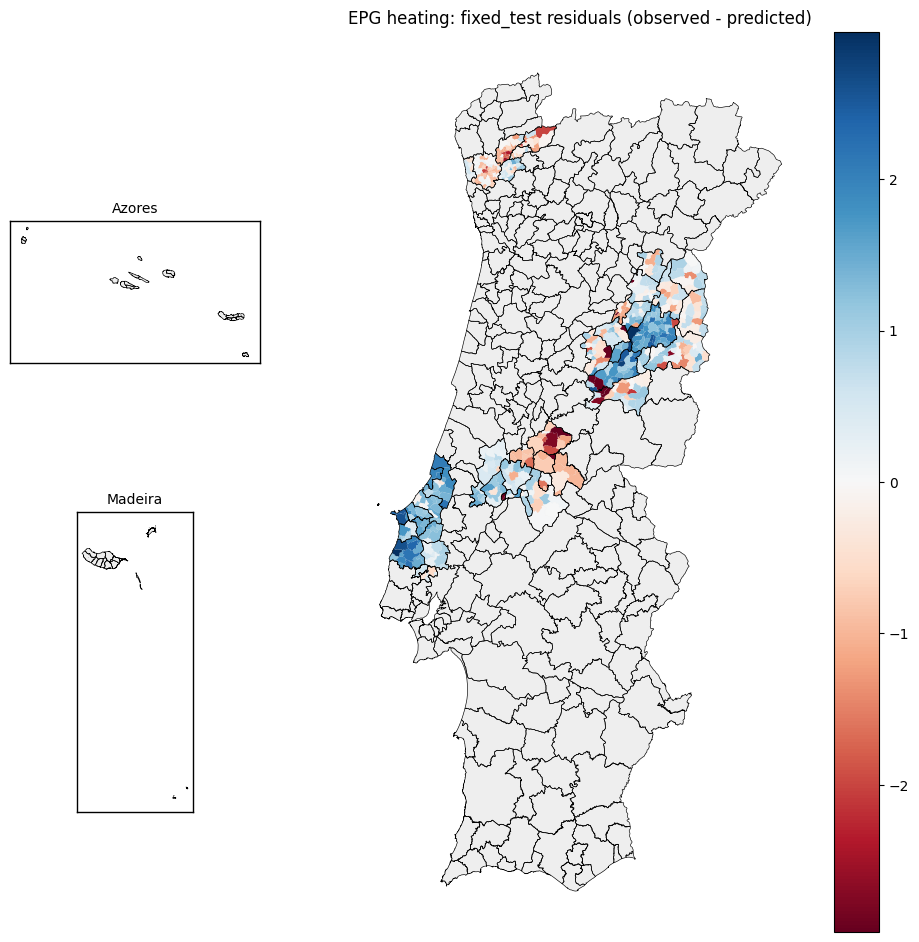

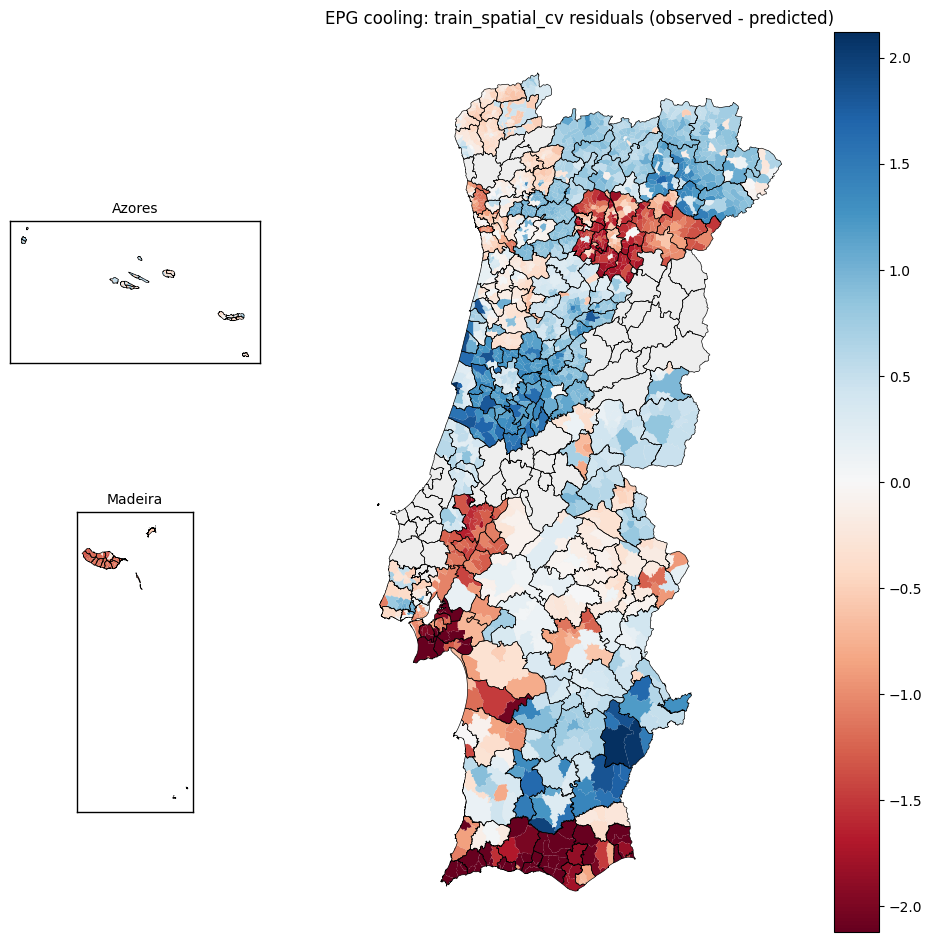

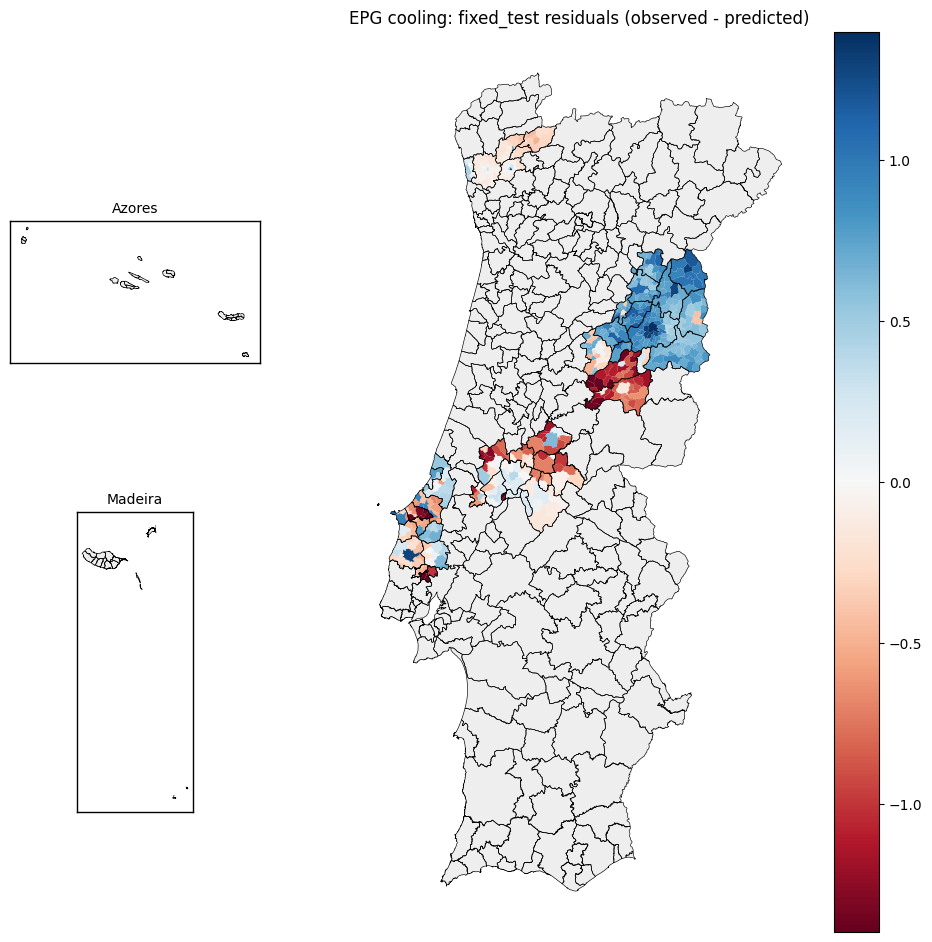

In [7]:
parishes = gpd.read_file(PARISH_GEOMETRY_GEOJSON)[["dicofre", "geometry"]].copy()
parishes["ID_norm"] = rf_utils.normalize_id(parishes["dicofre"])
nuts3_mapping = rf_utils.load_nuts3_mapping(repo_data_path(PATHS, "freguesias_to_NUTS3.csv"))
parishes = parishes.merge(nuts3_mapping, on="ID_norm", how="left")
parishes["municipality_id"] = parishes["ID_norm"].str[:4]

def add_bounds(ax, gdf):
    minx, miny, maxx, maxy = gdf.total_bounds
    padx = (maxx - minx) * 0.05 if maxx > minx else 1
    pady = (maxy - miny) * 0.05 if maxy > miny else 1
    ax.set_xlim(minx - padx, maxx + padx)
    ax.set_ylim(miny - pady, maxy + pady)
    ax.set_xticks([])
    ax.set_yticks([])

def residual_map(target: str, role: str):
    residuals = epg_predictions.query("target == @target and prediction_role == @role")[["ID_norm", "residual"]]
    gdf = parishes.merge(residuals, on="ID_norm", how="left")
    mainland = gdf.loc[~gdf["NUTS3"].isin(["PT200", "PT300"])].copy()
    azores = gdf.loc[gdf["NUTS3"].eq("PT200")].copy()
    madeira = gdf.loc[gdf["NUTS3"].eq("PT300")].copy()
    municipality_boundaries = {
        "mainland": mainland.dissolve(by="municipality_id").boundary,
        "azores": azores.dissolve(by="municipality_id").boundary,
        "madeira": madeira.dissolve(by="municipality_id").boundary,
    }
    finite = gdf["residual"].dropna().abs()
    limit = max(float(finite.quantile(0.98)) if not finite.empty else 1.0, 0.1)
    norm = TwoSlopeNorm(vmin=-limit, vcenter=0, vmax=limit)
    fig = plt.figure(figsize=(10, 10))
    ax_main = fig.add_axes([0.33, 0.05, 0.64, 0.90])
    ax_azores = fig.add_axes([0.05, 0.54, 0.25, 0.30], frameon=True)
    ax_madeira = fig.add_axes([0.05, 0.17, 0.25, 0.30], frameon=True)
    for ax, part, boundary_key, legend in [(ax_main, mainland, "mainland", True), (ax_azores, azores, "azores", False), (ax_madeira, madeira, "madeira", False)]:
        part.plot(ax=ax, color="#eeeeee", linewidth=0)
        part.plot(ax=ax, column="residual", cmap="RdBu", norm=norm, legend=legend, linewidth=0, missing_kwds={"color": "#eeeeee"})
        municipality_boundaries[boundary_key].plot(ax=ax, color="black", linewidth=0.45, zorder=20)
        add_bounds(ax, part)
        ax.set_facecolor("white")
    ax_main.set_axis_off()
    ax_main.set_title(f"{target}: {role} residuals (observed - predicted)")
    ax_azores.set_title("Azores", fontsize=10)
    ax_madeira.set_title("Madeira", fontsize=10)
    for ax in [ax_azores, ax_madeira]:
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color("black")
            spine.set_linewidth(1.0)
    plt.show()

for target in EPG_TARGETS:
    residual_map(target, "train_spatial_cv")
    residual_map(target, "fixed_test")

## Predictor and Residual Diagnostics

Impurity importance describes the final training-fit forest, not causality. Residual correlations below ask a different question: which allowed predictors still align with EPG errors under spatial transfer?

In [8]:
SAT_CSV, _, _ = rf_utils.choose_satellite_csv(PATHS, repo_data_path, path_value)
inputs = rf_utils.load_prediction_inputs(
    sat_csv=SAT_CSV,
    adm_csv=repo_data_path(PATHS, "all_used_adm_indicators.csv"),
    epvi_csv=path_value(PATHS, "epvi_csv"),
    adm_split_json=repo_data_path(PATHS, "adm_data_split.json"),
)
model_df, predictor_cols, _ = rf_utils.build_modeling_table(inputs)
model_df = rf_utils.attach_nuts3(model_df, nuts3_mapping)

for target in EPG_TARGETS:
    print("\n", target)
    display(epg_importances[epg_importances["target"].eq(target)].nlargest(15, "impurity_importance"))

residual_feature_rows = []
for target in EPG_TARGETS:
    for role in ["train_spatial_cv", "fixed_test"]:
        part = epg_predictions.query("target == @target and prediction_role == @role")[["ID_norm", "residual"]]
        joined = part.merge(model_df[["ID_norm", *predictor_cols]], on="ID_norm", how="left")
        for feature in predictor_cols:
            corr = joined[["residual", feature]].corr(method="spearman").iloc[0, 1]
            residual_feature_rows.append({"target": target, "prediction_role": role, "feature": feature, "residual_spearman": corr})
residual_feature_corr = pd.DataFrame(residual_feature_rows)
residual_feature_corr["abs_residual_spearman"] = residual_feature_corr["residual_spearman"].abs()
display(
    residual_feature_corr.sort_values("abs_residual_spearman", ascending=False)
    .groupby(["target", "prediction_role"], as_index=False, observed=True)
    .head(12)
)


 EPG heating


,target,feature,impurity_importance
0,EPG heating,extreme_cold,0.133509
1,EPG heating,hdd_18,0.093015
2,EPG heating,share_of_superior_edu,0.063394
3,EPG heating,age_x_height,0.059505
4,EPG heating,av_built_up_density,0.059447
5,EPG heating,age_x_res_vol,0.057221
6,EPG heating,av_h,0.051554
7,EPG heating,av_1_over_h,0.043334
8,EPG heating,ntl,0.041513
9,EPG heating,pop_density,0.031692



 EPG cooling


,target,feature,impurity_importance
48,EPG cooling,hdd_18,0.182674
49,EPG cooling,extreme_cold,0.150771
50,EPG cooling,cdd_25,0.077632
51,EPG cooling,ntl,0.072609
52,EPG cooling,extreme_heat,0.066885
53,EPG cooling,delta_oc_per_capita,0.038788
54,EPG cooling,av_built_up_density,0.036153
55,EPG cooling,standard_delta_oc,0.034278
56,EPG cooling,standard_delta_bc,0.032903
57,EPG cooling,energy_per_vol_per_capita,0.028964


,target,prediction_role,feature,residual_spearman,abs_residual_spearman
187,EPG cooling,fixed_test,extreme_cold,-0.485229,0.485229
147,EPG cooling,fixed_test,res_vol_per_capita,0.395881,0.395881
176,EPG cooling,fixed_test,standard_delta_pm_25,-0.361786,0.361786
175,EPG cooling,fixed_test,delta_pm_25,-0.348660,0.348660
181,EPG cooling,fixed_test,delta_oc,-0.338481,0.338481
178,EPG cooling,fixed_test,delta_bc,-0.337953,0.337953
159,EPG cooling,fixed_test,pop_density,-0.324904,0.324904
169,EPG cooling,fixed_test,energy_per_vol_per_capita,-0.278706,0.278706
71,EPG heating,fixed_test,ntl,0.277535,0.277535
152,EPG cooling,fixed_test,share_pre_1975_buildings,0.273113,0.273113


## Readout Checklist

- If EPG random forests do not beat the mean baselines in fixed test or spatial CV, stop narrowing RF hyperparameters.
- If NUTS3 regional means are badly shifted or compressed, compare target distributions and consider explicit spatial baselines or region-transfer framing.
- If residual maps show contiguous regional errors, treat that as remaining spatial structure not learned from allowed predictors.
- If basic administrative variables dominate the EPG residual correlations, separate satellite-only and basic-admin-only baselines before interpreting satellite predictability.
